<a href="https://colab.research.google.com/github/fbyprl29/EndemiKita/blob/main/Analisis_Realisasi_Data_Inaproc_Prov_DKI_Jakarta_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving data_realisasi_20260913_214859.csv to data_realisasi_20260913_214859.csv
Saving data_rup_20260913_214715.csv to data_rup_20260913_214715.csv


In [3]:
df_rup = pd.read_csv("data_rup_20260913_214715.csv")
df_real = pd.read_csv("data_realisasi_20260913_214859.csv")

In [4]:
print("Ukuran Dataset RUP       :", df_rup.shape)
print("Ukuran Dataset Realisasi :", df_real.shape)

Ukuran Dataset RUP       : (73885, 11)
Ukuran Dataset Realisasi : (134407, 16)


In [5]:
print("Kolom RUP:")
print(df_rup.columns.tolist())

print("\nKolom Realisasi:")
print(df_real.columns.tolist())

Kolom RUP:
['nama_instansi', 'nama_satuan_kerja', 'tahun_anggaran', 'cara_pengadaan', 'metode_pengadaan', 'jenis_pengadaan', 'nama_paket', 'kode_rup', 'sumber_dana', 'produk_dalam_negeri', 'total_nilai']

Kolom Realisasi:
['nama_instansi', 'nama_satuan_kerja', 'kode_paket', 'kode_rup', 'tahun_anggaran', 'sumber_transaksi', 'sumber_dana', 'nama_penyedia', 'metode_pengadaan', 'jenis_pengadaan', 'nama_paket', 'status_paket', 'tahapan_pengadaan', 'total_nilai', 'nilai_pdn', 'nilai_umk']


In [6]:
display(df_rup.head())
display(df_real.head())

,nama_instansi,nama_satuan_kerja,tahun_anggaran,cara_pengadaan,metode_pengadaan,jenis_pengadaan,nama_paket,kode_rup,sumber_dana,produk_dalam_negeri,total_nilai
0,PROVINSI DKI JAKARTA,DINAS PENANAMAN MODAL DAN PELAYANAN TERPADU SATU PINTU - 2.18.0.00.0.00.01.0000,2026,Penyedia,Pengadaan Langsung,Jasa Lainnya,Belanja Jasa Tenaga Pelayanan Umum Customer Relation Officer-99-S2,61971671,APBD,Ya,88560225
1,PROVINSI DKI JAKARTA,KELURAHAN MAMPANG PRAPATAN - JAKSEL - 7.01.0.00.0.00.04.0031,2026,Penyedia,E-Purchasing,Barang,Penyediaan Peralatan dan Perlengkapan kerja lapangan PPSU (Belanja Alat/Bahan untuk Kegiatan Kan...,63465038,APBD,Ya,31614240
2,PROVINSI DKI JAKARTA,"DINAS PEMBERDAYAAN, PERLINDUNGAN ANAK DAN PENGENDALIAN PENDUDUK - 2.08.2.14.0.00.01.0000",2026,Penyedia,Pengadaan Langsung,Jasa Lainnya,Penyediaan Jasa Tenaga Ahli Video Editor Semester II,65589680,APBD,Ya,122100000
3,PROVINSI DKI JAKARTA,PUSAT DATA DAN INFORMASI PERENCANAAN PEMBANGUNAN - 5.01.0.00.0.00.01.0008,2026,Penyedia,Pengadaan Langsung,Jasa Lainnya,Penyediaan Jasa Lainnya Perorangan Desain Grafis 3,67294939,APBD,Ya,63250000
4,PROVINSI DKI JAKARTA,KELURAHAN JATINEGARA - JAKTIM - 7.01.0.00.0.00.05.0069,2026,Penyedia,E-Purchasing,Barang,Penyediaan Kesekretariatan LMK - Penyediaan Makanan dan Minuman Rakoor Mingguan LMK,63297991,APBD,Ya,29216000


,nama_instansi,nama_satuan_kerja,kode_paket,kode_rup,tahun_anggaran,sumber_transaksi,sumber_dana,nama_penyedia,metode_pengadaan,jenis_pengadaan,nama_paket,status_paket,tahapan_pengadaan,total_nilai,nilai_pdn,nilai_umk
0,PROVINSI DKI JAKARTA,INSPEKTORAT PEMBANTU WILAYAH KOTA - JAKPUS - 6.01.0.00.0.00.01.0001,01KGRE7CHRHZEG0SAA20FYF17M,64262655,2026,E-Katalog Versi 6.0,APBD,PRISMACO JAYA INDONESIA,E-Purchasing,Jasa Lainnya,Belanja Sewa Alat Reproduksi (Penggandaan),ON PROCESS,Kontrak,53835000,53835000,53835000
1,PROVINSI DKI JAKARTA,SUKU DINAS LINGKUNGAN HIDUP KOTA ADMINISTRASI JAKARTA BARAT - 2.11.0.00.0.00.01.0003,10742714000,62364425,2026,Non Tender,APBD,SAKIMAN,Pengadaan Langsung,Jasa Lainnya,Petugas Pengolahan Sampah - Kru Angkutan Sampah 322,SELESAI,Pemilihan Selesai,71753175,71753175,71753175
2,PROVINSI DKI JAKARTA,KELURAHAN BATU AMPAR - JAKTIM - 7.01.0.00.0.00.05.0026,01KEX46DFCSRHXSS5V6750J3DS,62339708,2026,E-Katalog Versi 6.0,APBD,USAHA BERSAMA JAYA ABADI,E-Purchasing,Jasa Lainnya,Penyediaan Jasa Peralatan dan Perlengkapan Kantor (sewa mesin fotokopi),ON PROCESS,Kontrak,55278000,55278000,55278000
3,PROVINSI DKI JAKARTA,KELURAHAN SUNGAI BAMBU - JAKUT - 7.01.0.00.0.00.02.0016,10640004000,61887137,2026,Non Tender,APBD,Rifal Fredika,Pengadaan Langsung,Jasa Lainnya,Pembayaran GAJI PPSU 56 (RIFAL FREDIKA),SELESAI,Pemilihan Selesai,70157893,70157893,70157893
4,PROVINSI DKI JAKARTA,SATUAN POLISI PAMONG PRAJA - 1.05.0.00.0.00.01.0000,11018468000,66893427,2026,Non Tender,APBD,Fatan Kasyidi,Pengadaan Langsung,Jasa Konsultansi Perorangan Non Konstruksi,"Tenaga Ahli Sistem Informasi Frontend Mobile Enginner (FME) Modul 4 - Peralatan, Perlengkapan, J...",SELESAI,Pemilihan Selesai,65000000,65000000,65000000


In [7]:
df_rup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73885 entries, 0 to 73884
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   nama_instansi        73885 non-null  object
 1   nama_satuan_kerja    73885 non-null  object
 2   tahun_anggaran       73885 non-null  int64 
 3   cara_pengadaan       73885 non-null  object
 4   metode_pengadaan     73885 non-null  object
 5   jenis_pengadaan      73885 non-null  object
 6   nama_paket           73885 non-null  object
 7   kode_rup             73885 non-null  int64 
 8   sumber_dana          73871 non-null  object
 9   produk_dalam_negeri  73885 non-null  object
 10  total_nilai          73885 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 6.2+ MB


In [8]:
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134407 entries, 0 to 134406
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   nama_instansi      134407 non-null  object
 1   nama_satuan_kerja  134407 non-null  object
 2   kode_paket         134407 non-null  object
 3   kode_rup           134404 non-null  object
 4   tahun_anggaran     134407 non-null  int64 
 5   sumber_transaksi   134407 non-null  object
 6   sumber_dana        134404 non-null  object
 7   nama_penyedia      134407 non-null  object
 8   metode_pengadaan   134407 non-null  object
 9   jenis_pengadaan    133344 non-null  object
 10  nama_paket         134404 non-null  object
 11  status_paket       134404 non-null  object
 12  tahapan_pengadaan  134407 non-null  object
 13  total_nilai        134407 non-null  int64 
 14  nilai_pdn          134407 non-null  object
 15  nilai_umk          134407 non-null  object
dtypes: int64(2), object(

In [9]:
print("Missing Value RUP")
display(df_rup.isnull().sum())

print("\nMissing Value Realisasi")
display(df_real.isnull().sum())

Missing Value RUP


,0
nama_instansi,0
nama_satuan_kerja,0
tahun_anggaran,0
cara_pengadaan,0
metode_pengadaan,0
jenis_pengadaan,0
nama_paket,0
kode_rup,0
sumber_dana,14
produk_dalam_negeri,0



Missing Value Realisasi


,0
nama_instansi,0
nama_satuan_kerja,0
kode_paket,0
kode_rup,3
tahun_anggaran,0
sumber_transaksi,0
sumber_dana,3
nama_penyedia,0
metode_pengadaan,0
jenis_pengadaan,1063


In [10]:
print("Duplikat baris RUP       :", df_rup.duplicated().sum())
print("Duplikat baris Realisasi :", df_real.duplicated().sum())

Duplikat baris RUP       : 0
Duplikat baris Realisasi : 0


In [13]:
print(
    "Jumlah Kode RUP unik:",
    df_rup["kode_rup"].nunique()
)

print(
    "Jumlah baris RUP:",
    len(df_rup)
)

Jumlah Kode RUP unik: 73885
Jumlah baris RUP: 73885


In [14]:
print("Tahun RUP:")
print(df_rup["tahun_anggaran"].value_counts())

print("\nTahun Realisasi:")
print(df_real["tahun_anggaran"].value_counts())

Tahun RUP:
tahun_anggaran
2026    73885
Name: count, dtype: int64

Tahun Realisasi:
tahun_anggaran
2026    134407
Name: count, dtype: int64


In [18]:
df_rup["kode_rup"] = (
    df_rup["kode_rup"]
    .astype("string")
    .str.strip()
)

df_real["kode_rup"] = (
    df_real["kode_rup"]
    .astype("string")
    .str.strip()
)

In [19]:
print("Kode RUP kosong:", df_rup["kode_rup"].isna().sum())
print("Kode RUP Realisasi kosong:", df_real["kode_rup"].isna().sum())

Kode RUP kosong: 0
Kode RUP Realisasi kosong: 3


In [20]:
df_penyedia = df_rup[
    df_rup["cara_pengadaan"] == "Penyedia"
].copy()

In [21]:
print(
    "Total perencanaan melalui Penyedia:",
    len(df_penyedia)
)

Total perencanaan melalui Penyedia: 63745


In [22]:
metode_awal = (
    df_penyedia
    .groupby("metode_pengadaan")
    .agg(
        jumlah_paket=("kode_rup", "nunique"),
        total_nilai=("total_nilai", "sum")
    )
    .reset_index()
    .sort_values("jumlah_paket", ascending=False)
)

display(metode_awal)

,metode_pengadaan,jumlah_paket,total_nilai
1,E-Purchasing,39750,12123860299746
3,Pengadaan Langsung,15444,8728992822534
0,Dikecualikan,6870,7909651469180
4,Penunjukan Langsung,1055,125417309322
5,Seleksi,488,195703879327
6,Tender,70,830105564195
2,Pembayaran untuk Kontrak Tahun Jamak,67,3490450388381
7,Tender Cepat,1,4942738192


In [23]:
realisasi_per_rup = (
    df_real
    .groupby("kode_rup")
    .agg(
        jumlah_paket_realisasi=("kode_paket", "nunique"),
        total_realisasi=("total_nilai", "sum")
    )
    .reset_index()
)

In [24]:
display(realisasi_per_rup.head())

,kode_rup,jumlah_paket_realisasi,total_realisasi
0,41246622,1,11650000
1,41247082,1,82500000
2,41247099,1,990000000
3,41247110,1,103125000
4,41247281,1,550000


In [25]:
print(
    "Jumlah Kode RUP pada data realisasi:",
    realisasi_per_rup["kode_rup"].nunique()
)

Jumlah Kode RUP pada data realisasi: 27563


In [26]:
#left join
df_analysis = df_penyedia.merge(
    realisasi_per_rup,
    on="kode_rup",
    how="left"
)

In [27]:
df_analysis["jumlah_paket_realisasi"] = (
    df_analysis["jumlah_paket_realisasi"]
    .fillna(0)
)

df_analysis["total_realisasi"] = (
    df_analysis["total_realisasi"]
    .fillna(0)
)

In [31]:
df_analysis["persentase_realisasi"] = df_analysis["total_realisasi"] / df_analysis["total_nilai"]
df_analysis["persentase_realisasi"] = (
    df_analysis["persentase_realisasi"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [32]:
def tentukan_status(row):
    if row["total_realisasi"] == 0:
        return "BELUM TEREALISASI"
    elif row["total_realisasi"] < row["total_nilai"]:
        return "SEBAGIAN TEREALISASI"
    else:
        return "TEREALISASI PENUH/≥ PAGU"

df_analysis["status_realisasi"] = (
    df_analysis.apply(tentukan_status, axis=1)
)

In [33]:
display(
    df_analysis["status_realisasi"]
    .value_counts()
    .to_frame("jumlah")
)

,jumlah
status_realisasi,
BELUM TEREALISASI,37874
SEBAGIAN TEREALISASI,21841
TEREALISASI PENUH/≥ PAGU,4030


In [34]:
belum_realisasi = df_analysis[
    df_analysis["status_realisasi"] == "BELUM TEREALISASI"
].copy()

In [35]:
belum_realisasi = belum_realisasi.sort_values(
    "total_nilai",
    ascending=False
)

In [36]:
kolom_hasil = [
    "kode_rup",
    "nama_instansi",
    "nama_satuan_kerja",
    "nama_paket",
    "metode_pengadaan",
    "jenis_pengadaan",
    "total_nilai",
    "total_realisasi",
    "persentase_realisasi",
    "status_realisasi"
]

display(
    belum_realisasi[kolom_hasil].head(20)
)

,kode_rup,nama_instansi,nama_satuan_kerja,nama_paket,metode_pengadaan,jenis_pengadaan,total_nilai,total_realisasi,persentase_realisasi,status_realisasi
17794,64127442,PROVINSI DKI JAKARTA,"DINAS CIPTA KARYA, TATA RUANG DAN PERTANAHAN - 1.03.0.00.0.00.03.0000",Jasa Konstruksi Pembangunan Gedung Batavia Dinas Teknis Jatibaru,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,303211680659,0.00,0.00,BELUM TEREALISASI
35544,64853880,PROVINSI DKI JAKARTA,DINAS SUMBER DAYA AIR - 1.03.0.00.0.00.02.0000,Pekerjaan Konstruksi Jaringan Pipa Air Limbah Jakarta Sewerage Development Project Zone 1 Paket ...,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,290760927966,0.00,0.00,BELUM TEREALISASI
20380,66150672,PROVINSI DKI JAKARTA,RUMAH SAKIT UMUM DAERAH KOJA - 1.02.0.00.0.00.01.0057,Belanja Barang dan Jasa BLUD (BLUD TA 2026)Rev I,Dikecualikan,Barang,274694869081,0.00,0.00,BELUM TEREALISASI
45582,65152849,PROVINSI DKI JAKARTA,DINAS PENDIDIKAN - 1.01.0.00.0.00.01.0000,Belanja Barang dan Jasa BOSP-BOS Reguler Penyediaan Bantuan Operasional Sekolah (BOS) Reguler Je...,Dikecualikan,Jasa Lainnya,265104724828,0.00,0.00,BELUM TEREALISASI
5800,64600504,PROVINSI DKI JAKARTA,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN - 1.04.0.00.0.00.01.0000,Pelaksanaan Fisik Pembangunan Rumah Susun Padat Karya Tahap II,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,260817304784,0.00,0.00,BELUM TEREALISASI
31164,64452717,PROVINSI DKI JAKARTA,DINAS BINA MARGA - 1.03.0.00.0.00.01.0000,Pekerjaan Konstruksi Terintegrasi Rancang dan Bangun Flyover (FO) Latumeten,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,233624094748,0.00,0.00,BELUM TEREALISASI
52648,64665982,PROVINSI DKI JAKARTA,DINAS BINA MARGA - 1.03.0.00.0.00.01.0000,Pembayaran Rekening Listrik PJU,Dikecualikan,Jasa Lainnya,226600000000,0.00,0.00,BELUM TEREALISASI
1124,65153812,PROVINSI DKI JAKARTA,DINAS PENDIDIKAN - 1.01.0.00.0.00.01.0000,Belanja Modal Peralatan dan Mesin BOSP-BOS Reguler Penyediaan Bantuan Operasional Sekolah (BOS) ...,Dikecualikan,Jasa Lainnya,223775937643,0.00,0.00,BELUM TEREALISASI
54776,67284132,PROVINSI DKI JAKARTA,DINAS KESEHATAN - 1.02.0.00.0.00.01.0000,Pekerjaan Konstruksi Pembangunan RSUD Cakung,Tender,Pekerjaan Konstruksi,203592121600,0.00,0.00,BELUM TEREALISASI
42292,64853951,PROVINSI DKI JAKARTA,DINAS SUMBER DAYA AIR - 1.03.0.00.0.00.02.0000,Pekerjaan Konstruksi Jaringan Pipa Air Limbah Jakarta Sewerage Development Project Zone 1 Paket ...,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,171054770856,0.00,0.00,BELUM TEREALISASI


In [37]:
jumlah_belum = (
    belum_realisasi["kode_rup"]
    .nunique()
)

nilai_belum = (
    belum_realisasi["total_nilai"]
    .sum()
)

print("Jumlah pengadaan belum terealisasi :", jumlah_belum)
print("Total nilai belum terealisasi      :", nilai_belum)

Jumlah pengadaan belum terealisasi : 37874
Total nilai belum terealisasi      : 13876360419237


In [38]:
print(
    f"Rp {nilai_belum:,.0f}".replace(",", ".")
)

Rp 13.876.360.419.237


In [39]:
belum_per_metode = (
    belum_realisasi
    .groupby("metode_pengadaan")
    .agg(
        jumlah_pengadaan=("kode_rup", "nunique"),
        total_nilai_belum=("total_nilai", "sum")
    )
    .reset_index()
    .sort_values(
        "jumlah_pengadaan",
        ascending=False
    )
)

display(belum_per_metode)

,metode_pengadaan,jumlah_pengadaan,total_nilai_belum
1,E-Purchasing,23053,2929060282473
3,Pengadaan Langsung,7515,1909716163542
0,Dikecualikan,6231,5029387738418
4,Penunjukan Langsung,890,72898868029
5,Seleksi,92,51866723937
2,Pembayaran untuk Kontrak Tahun Jamak,67,3490450388381
6,Tender,25,388037516265
7,Tender Cepat,1,4942738192


In [40]:
#Hitung tingkat realisasi per metodenya
total_per_metode = (
    df_penyedia
    .groupby("metode_pengadaan")
    .agg(
        total_pengadaan=("kode_rup", "nunique"),
        total_nilai=("total_nilai", "sum")
    )
    .reset_index()
)

belum_summary = (
    belum_realisasi
    .groupby("metode_pengadaan")
    .agg(
        belum_realisasi=("kode_rup", "nunique"),
        nilai_belum=("total_nilai", "sum")
    )
    .reset_index()
)

summary_metode = total_per_metode.merge(
    belum_summary,
    on="metode_pengadaan",
    how="left"
)

summary_metode[
    ["belum_realisasi", "nilai_belum"]
] = summary_metode[
    ["belum_realisasi", "nilai_belum"]
].fillna(0)

summary_metode["persentase_belum"] = (
    summary_metode["belum_realisasi"]
    / summary_metode["total_pengadaan"]
    * 100
)

summary_metode["persentase_nilai_belum"] = (
    summary_metode["nilai_belum"]
    / summary_metode["total_nilai"]
    * 100
)

display(
    summary_metode.sort_values(
        "persentase_belum",
        ascending=False
    )
)

,metode_pengadaan,total_pengadaan,total_nilai,belum_realisasi,nilai_belum,persentase_belum,persentase_nilai_belum
2,Pembayaran untuk Kontrak Tahun Jamak,67,3490450388381,67,3490450388381,100.00,100.00
7,Tender Cepat,1,4942738192,1,4942738192,100.00,100.00
0,Dikecualikan,6870,7909651469180,6231,5029387738418,90.70,63.59
4,Penunjukan Langsung,1055,125417309322,890,72898868029,84.36,58.13
1,E-Purchasing,39750,12123860299746,23053,2929060282473,57.99,24.16
3,Pengadaan Langsung,15444,8728992822534,7515,1909716163542,48.66,21.88
6,Tender,70,830105564195,25,388037516265,35.71,46.75
5,Seleksi,488,195703879327,92,51866723937,18.85,26.50


In [41]:
top10_belum = (
    belum_realisasi[
        [
            "kode_rup",
            "nama_satuan_kerja",
            "nama_paket",
            "metode_pengadaan",
            "jenis_pengadaan",
            "total_nilai"
        ]
    ]
    .sort_values(
        "total_nilai",
        ascending=False
    )
    .head(10)
)

display(top10_belum)

,kode_rup,nama_satuan_kerja,nama_paket,metode_pengadaan,jenis_pengadaan,total_nilai
17794,64127442,"DINAS CIPTA KARYA, TATA RUANG DAN PERTANAHAN - 1.03.0.00.0.00.03.0000",Jasa Konstruksi Pembangunan Gedung Batavia Dinas Teknis Jatibaru,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,303211680659
35544,64853880,DINAS SUMBER DAYA AIR - 1.03.0.00.0.00.02.0000,Pekerjaan Konstruksi Jaringan Pipa Air Limbah Jakarta Sewerage Development Project Zone 1 Paket ...,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,290760927966
20380,66150672,RUMAH SAKIT UMUM DAERAH KOJA - 1.02.0.00.0.00.01.0057,Belanja Barang dan Jasa BLUD (BLUD TA 2026)Rev I,Dikecualikan,Barang,274694869081
45582,65152849,DINAS PENDIDIKAN - 1.01.0.00.0.00.01.0000,Belanja Barang dan Jasa BOSP-BOS Reguler Penyediaan Bantuan Operasional Sekolah (BOS) Reguler Je...,Dikecualikan,Jasa Lainnya,265104724828
5800,64600504,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN - 1.04.0.00.0.00.01.0000,Pelaksanaan Fisik Pembangunan Rumah Susun Padat Karya Tahap II,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,260817304784
31164,64452717,DINAS BINA MARGA - 1.03.0.00.0.00.01.0000,Pekerjaan Konstruksi Terintegrasi Rancang dan Bangun Flyover (FO) Latumeten,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,233624094748
52648,64665982,DINAS BINA MARGA - 1.03.0.00.0.00.01.0000,Pembayaran Rekening Listrik PJU,Dikecualikan,Jasa Lainnya,226600000000
1124,65153812,DINAS PENDIDIKAN - 1.01.0.00.0.00.01.0000,Belanja Modal Peralatan dan Mesin BOSP-BOS Reguler Penyediaan Bantuan Operasional Sekolah (BOS) ...,Dikecualikan,Jasa Lainnya,223775937643
54776,67284132,DINAS KESEHATAN - 1.02.0.00.0.00.01.0000,Pekerjaan Konstruksi Pembangunan RSUD Cakung,Tender,Pekerjaan Konstruksi,203592121600
42292,64853951,DINAS SUMBER DAYA AIR - 1.03.0.00.0.00.02.0000,Pekerjaan Konstruksi Jaringan Pipa Air Limbah Jakarta Sewerage Development Project Zone 1 Paket ...,Pembayaran untuk Kontrak Tahun Jamak,Pekerjaan Konstruksi,171054770856


In [42]:
#berdasarkan jenis pengadaan
belum_per_jenis = (
    belum_realisasi
    .groupby("jenis_pengadaan")
    .agg(
        jumlah_pengadaan=("kode_rup", "nunique"),
        total_nilai=("total_nilai", "sum")
    )
    .reset_index()
    .sort_values(
        "total_nilai",
        ascending=False
    )
)

display(belum_per_jenis)

,jenis_pengadaan,jumlah_pengadaan,total_nilai
3,Jasa Lainnya,13946,5521426104126
4,Pekerjaan Konstruksi,651,4385889338560
1,Barang,21841,3603732236158
2,Jasa Konsultansi,1394,351730298754
5,Terintegrasi,41,13576527539
0,-,1,5914100


In [43]:
#berdasarkan satuan kerja
belum_per_satker = (
    belum_realisasi
    .groupby("nama_satuan_kerja")
    .agg(
        jumlah_pengadaan=("kode_rup", "nunique"),
        total_nilai=("total_nilai", "sum")
    )
    .reset_index()
    .sort_values(
        "total_nilai",
        ascending=False
    )
)

display(belum_per_satker.head(10))

,nama_satuan_kerja,jumlah_pengadaan,total_nilai
40,DINAS SUMBER DAYA AIR - 1.03.0.00.0.00.02.0000,379,2730242791843
33,DINAS PENDIDIKAN - 1.01.0.00.0.00.01.0000,182,1119070372507
20,DINAS BINA MARGA - 1.03.0.00.0.00.01.0000,228,672443981575
38,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN - 1.04.0.00.0.00.01.0000,105,629408221186
496,RUMAH SAKIT UMUM DAERAH KOJA - 1.02.0.00.0.00.01.0057,7,375317566177
21,"DINAS CIPTA KARYA, TATA RUANG DAN PERTANAHAN - 1.03.0.00.0.00.03.0000",55,327691767084
501,RUMAH SAKIT UMUM DAERAH PASAR MINGGU - 1.02.0.00.0.00.01.0063,62,323834706103
24,DINAS KESEHATAN - 1.02.0.00.0.00.01.0000,144,216565964917
643,SUKU DINAS PENDIDIKAN WILAYAH 1 KOTA - JAKBAR - 1.01.0.00.0.00.01.0005,82,173196791768
483,RUMAH SAKIT UMUM DAERAH CENGKARENG - 1.02.0.00.0.00.01.0059,29,171577804017


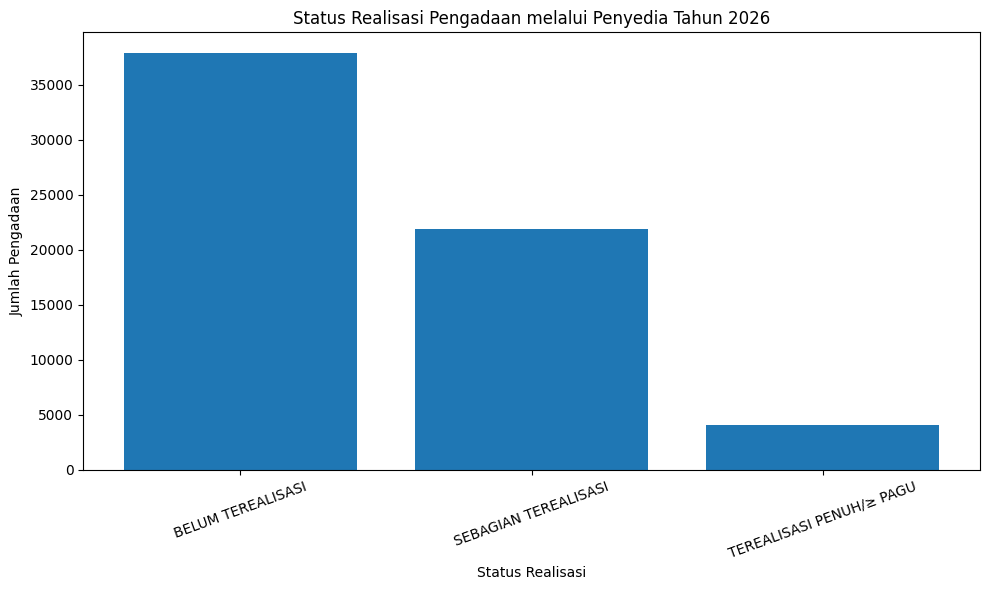

In [44]:
status_count = (
    df_analysis["status_realisasi"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_count.index,
    status_count.values
)

plt.title(
    "Status Realisasi Pengadaan melalui Penyedia Tahun 2026"
)

plt.xlabel("Status Realisasi")
plt.ylabel("Jumlah Pengadaan")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

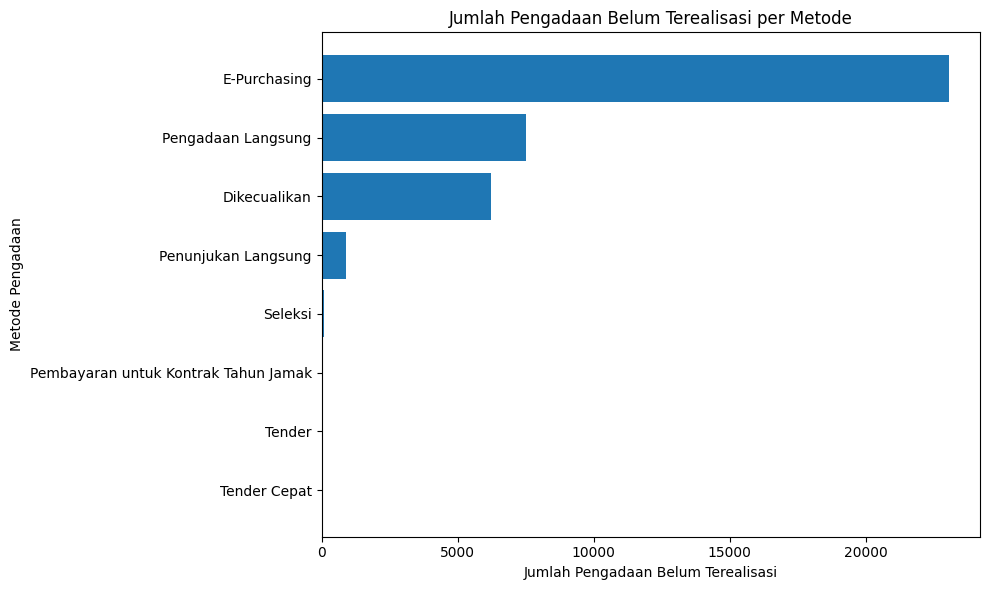

In [45]:
#visualisasi jumlah yang belum terealisasi per metode
plot_data = belum_per_metode.sort_values(
    "jumlah_pengadaan"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["metode_pengadaan"],
    plot_data["jumlah_pengadaan"]
)

plt.title(
    "Jumlah Pengadaan Belum Terealisasi per Metode"
)

plt.xlabel("Jumlah Pengadaan Belum Terealisasi")
plt.ylabel("Metode Pengadaan")

plt.tight_layout()
plt.show()

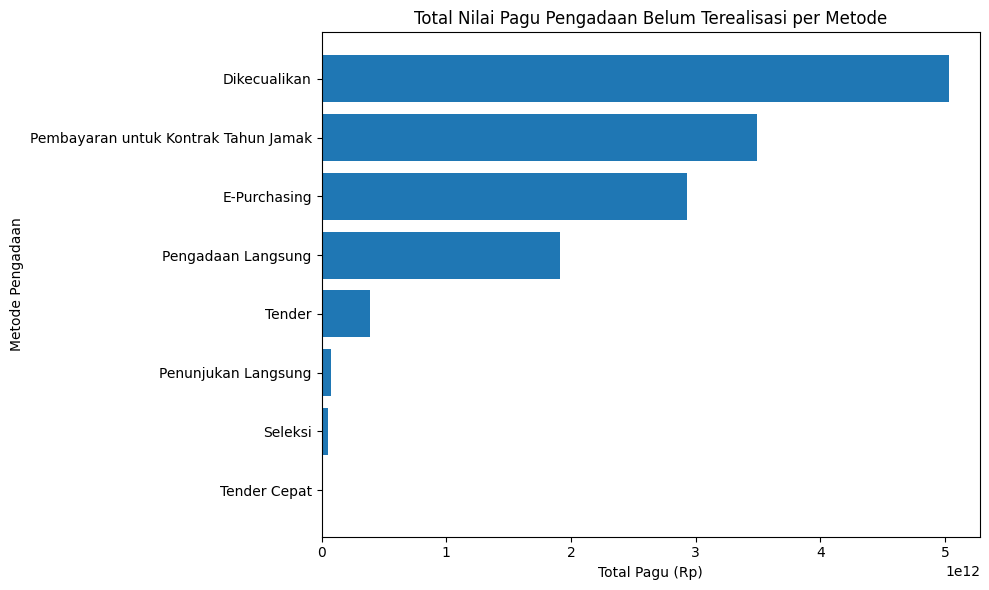

In [46]:
#visualisasi nilai pagu yang belum terealisasi
plot_nilai = belum_per_metode.sort_values(
    "total_nilai_belum"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_nilai["metode_pengadaan"],
    plot_nilai["total_nilai_belum"]
)

plt.title(
    "Total Nilai Pagu Pengadaan Belum Terealisasi per Metode"
)

plt.xlabel("Total Pagu (Rp)")
plt.ylabel("Metode Pengadaan")

plt.tight_layout()
plt.show()

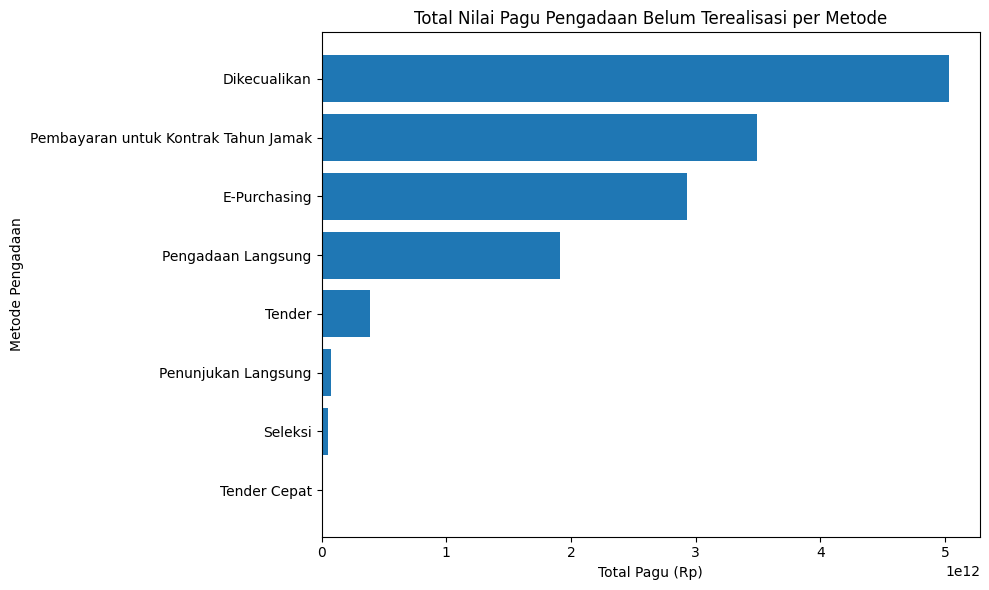

In [47]:
plot_nilai = belum_per_metode.sort_values(
    "total_nilai_belum"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_nilai["metode_pengadaan"],
    plot_nilai["total_nilai_belum"]
)

plt.title(
    "Total Nilai Pagu Pengadaan Belum Terealisasi per Metode"
)

plt.xlabel("Total Pagu (Rp)")
plt.ylabel("Metode Pengadaan")

plt.tight_layout()
plt.show()

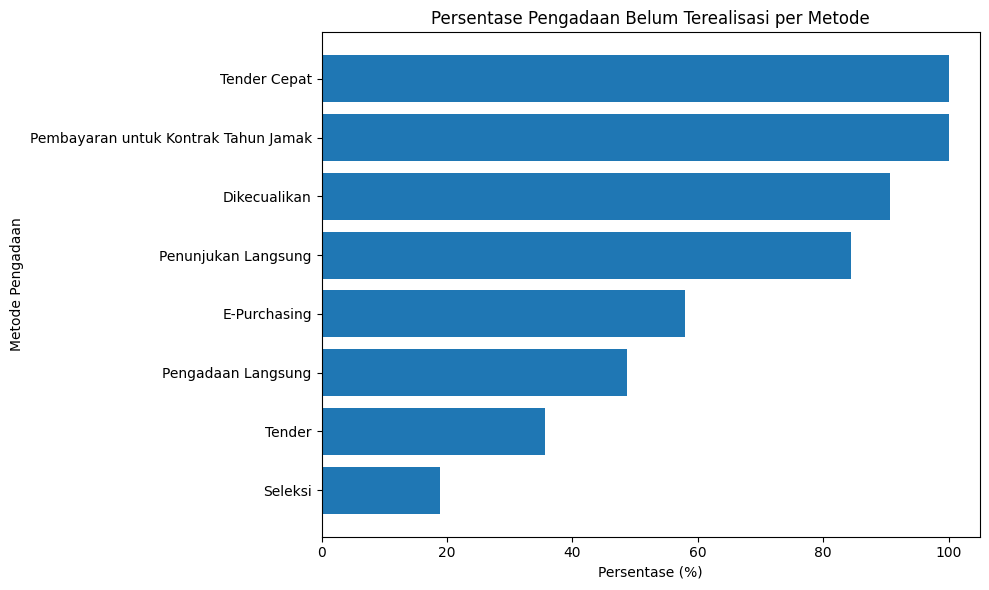

In [48]:
#visualisai metode berdasarkan persentase yang belum terealisasi
plot_proporsi = summary_metode.sort_values(
    "persentase_belum"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_proporsi["metode_pengadaan"],
    plot_proporsi["persentase_belum"]
)

plt.title(
    "Persentase Pengadaan Belum Terealisasi per Metode"
)

plt.xlabel("Persentase (%)")
plt.ylabel("Metode Pengadaan")

plt.tight_layout()
plt.show()

In [49]:
df_analysis.to_csv(
    "hasil_matching_rup_realisasi_2026.csv",
    index=False
)

belum_realisasi.to_csv(
    "pengadaan_belum_terealisasi_2026.csv",
    index=False
)

summary_metode.to_csv(
    "summary_belum_realisasi_per_metode.csv",
    index=False
)

In [50]:
from google.colab import files

files.download(
    "pengadaan_belum_terealisasi_2026.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>